#Big Data Analytics Final Project
## Predictive Insights for Apple Sales Data: Optimizing Product Strategy and Sales Performance

In this project, we aim to address the following questions using historical sales, product, and warranty data:

`Are there specific months in which product launches historically perform better in terms of sales?`

`Which store locations demonstrate the strongest sales performance, and are there locations that consistently underperform?`

`Can future sales and profit be forecasted for the upcoming month at the store or country level?`

With such a robust set of data, we chose not to limit the project to a single research question at the outset. Because the data is synthetic, we could not assume that any real-world trends would necessarily be present. Instead, we began with exploratory data analysis to identify meaningful patterns, after which we narrowed our focus to one or two questions based on the insights uncovered.

#Load, Aggregate and Clean Data

This was pretty straightforward, since this data is MLL generated, none of our files had any missing data. However, since every purcahse doesn't have a warranty, once we aggreagated we had to deal with those nulls. We inplaced with ""No Claim' but left claim date null.

In [1]:
!apt-get install openjdk-11-jdk-headless -qq
#!pip install pyspark --q
!pip install pyspark==3.4.2

Selecting previously unselected package openjdk-11-jre-headless:amd64.
(Reading database ... 117528 files and directories currently installed.)
Preparing to unpack .../openjdk-11-jre-headless_11.0.29+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jre-headless:amd64 (11.0.29+7-1ubuntu1~22.04) ...
Selecting previously unselected package openjdk-11-jdk-headless:amd64.
Preparing to unpack .../openjdk-11-jdk-headless_11.0.29+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jdk-headless:amd64 (11.0.29+7-1ubuntu1~22.04) ...
Setting up openjdk-11-jre-headless:amd64 (11.0.29+7-1ubuntu1~22.04) ...
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/jjs to provide /usr/bin/jjs (jjs) in auto mode
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/rmid to provide /usr/bin/rmid (rmid) in auto mode
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/pack200 to provide /usr/bin/pack200 (pack200) in auto mode
update-alternatives: using /usr/lib/jvm/jav

In [2]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

In [5]:
from pyspark.sql import SparkSession

spark = SparkSession\
.builder\
.appName("AppleSalesProject")\
.getOrCreate()


sc = spark.sparkContext

sales = spark.read.csv("sales.csv", header=True, inferSchema=True)
products = spark.read.csv("products.csv", header=True, inferSchema=True)
stores = spark.read.csv("stores.csv", header=True, inferSchema=True)
category = spark.read.csv("category.csv", header=True, inferSchema=True)
warranty = spark.read.csv("warranty.csv", header=True, inferSchema=True)

In [6]:
sales.show(5)

+---------+----------+--------+----------+--------+
|  sale_id| sale_date|store_id|product_id|quantity|
+---------+----------+--------+----------+--------+
|  YG-8782|16-06-2023|   ST-10|      P-38|      10|
|QX-999001|13-04-2022|   ST-63|      P-48|      10|
| JG-46890|05-07-2021|   ST-26|      P-79|       5|
|  XJ-1731|20-07-2022|   ST-15|      P-24|       9|
| FG-95080|18-03-2022|   ST-35|      P-69|       7|
+---------+----------+--------+----------+--------+
only showing top 5 rows



In [7]:
products.show(5)
category.show(5)
stores.show(5)
warranty.show(5)

+----------+-------------------+-----------+-----------+-----+
|Product_ID|       Product_Name|Category_ID|Launch_Date|Price|
+----------+-------------------+-----------+-----------+-----+
|       P-1|            MacBook|      CAT-1| 2023-09-17| 1149|
|       P-2|   MacBook Air (M1)|      CAT-1| 2023-11-11| 1783|
|       P-3|   MacBook Air (M2)|      CAT-1| 2020-05-24| 1588|
|       P-4|MacBook Pro 13-inch|      CAT-1| 2021-01-17| 1351|
|       P-5|MacBook Pro 14-inch|      CAT-1| 2024-05-12|  768|
+----------+-------------------+-----------+-----------+-----+
only showing top 5 rows

+-----------+-------------+
|category_id|category_name|
+-----------+-------------+
|      CAT-1|       Laptop|
|      CAT-2|        Audio|
|      CAT-3|       Tablet|
|      CAT-4|   Smartphone|
|      CAT-5|     Wearable|
+-----------+-------------+
only showing top 5 rows

+--------+--------------------+-------------+-------------+
|Store_ID|          Store_Name|         City|      Country|
+--------+-

In [8]:
merged_df = sales.join(
    stores,
    sales["store_id"] == stores["Store_ID"],
    how="inner"
)

merged_df = merged_df.drop(stores["Store_ID"])
merged_df.show(5)


+---------+----------+--------+----------+--------+--------------------+----------+-------------+
|  sale_id| sale_date|store_id|product_id|quantity|          Store_Name|      City|      Country|
+---------+----------+--------+----------+--------+--------------------+----------+-------------+
|  YG-8782|16-06-2023|   ST-10|      P-38|      10|Apple South Coast...|Costa Mesa|United States|
|QX-999001|13-04-2022|   ST-63|      P-48|      10|Apple Parque La C...|    Bogota|     Colombia|
| JG-46890|05-07-2021|   ST-26|      P-79|       5|   Apple Leidseplein| Amsterdam|  Netherlands|
|  XJ-1731|20-07-2022|   ST-15|      P-24|       9|Apple Downtown Br...|  Brooklyn|United States|
| FG-95080|18-03-2022|   ST-35|      P-69|       7|  Apple Shanghai IFC|  Shanghai|        China|
+---------+----------+--------+----------+--------+--------------------+----------+-------------+
only showing top 5 rows



In [9]:
#Check for row counts and nulls after merging sales and stores

row_count = merged_df.count()
col_count = len(merged_df.columns)

print(f"DataFrame has {row_count:,} rows and {col_count} columns.")


DataFrame has 123,791 rows and 8 columns.


In [10]:
from pyspark.sql import functions as F

null_counts = merged_df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in merged_df.columns
])

null_counts.show()

+-------+---------+--------+----------+--------+----------+----+-------+
|sale_id|sale_date|store_id|product_id|quantity|Store_Name|City|Country|
+-------+---------+--------+----------+--------+----------+----+-------+
|      0|        0|       0|         0|       0|         0|   0|      0|
+-------+---------+--------+----------+--------+----------+----+-------+



In [11]:
#Join merged w/ products
merged_df = merged_df.join(
    products,
    merged_df["product_id"] == products["Product_ID"],
    how="inner"
)

#Drop duplicate key column if both exist
merged_df = merged_df.drop(products["Product_ID"])


#Join merged w/ category
merged_df = merged_df.join(
    category,
    merged_df["Category_ID"] == category["category_id"],
    how="inner"
)

merged_df = merged_df.drop(category["Category_ID"])


#Join merged w/ warranty
merged_df = merged_df.join(
    warranty,
    on="sale_id",
    how="left"
)
print("After joining all:")
print(f"Rows: {merged_df.count():,}, Columns: {len(merged_df.columns)}")


#Since every sale does not have a warranty, we can fill nulls w/ no claim
merged_df = merged_df.fillna({
    "claim_id": "No Claim",
    "claim_date": "No Claim",
    "repair_status": "No Claim"
})


After joining all:
Rows: 123,791, Columns: 16


In [12]:
#Since every sale does not have a warranty, we can fill nulls w/ no claim
merged_df = merged_df.fillna({
    "claim_id": "No Claim",
    "claim_date": "No Claim",
    "repair_status": "No Claim"
})

In [13]:
null_counts = merged_df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in merged_df.columns
])

null_counts.show()

+-------+---------+--------+----------+--------+----------+----+-------+------------+-----------+-----------+-----+-------------+--------+----------+-------------+
|sale_id|sale_date|store_id|product_id|quantity|Store_Name|City|Country|Product_Name|Category_ID|Launch_Date|Price|category_name|claim_id|claim_date|repair_status|
+-------+---------+--------+----------+--------+----------+----+-------+------------+-----------+-----------+-----+-------------+--------+----------+-------------+
|      0|        0|       0|         0|       0|         0|   0|      0|           0|          0|          0|    0|            0|       0|     93791|            0|
+-------+---------+--------+----------+--------+----------+----+-------+------------+-----------+-----------+-----+-------------+--------+----------+-------------+



In [14]:
#claim_date is a date and so nulls cannot be replaces w a string
#we will leave it null for now


In [15]:
merged_df.printSchema()


root
 |-- sale_id: string (nullable = true)
 |-- sale_date: string (nullable = true)
 |-- store_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- Store_Name: string (nullable = true)
 |-- City: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Product_Name: string (nullable = true)
 |-- Category_ID: string (nullable = true)
 |-- Launch_Date: date (nullable = true)
 |-- Price: integer (nullable = true)
 |-- category_name: string (nullable = true)
 |-- claim_id: string (nullable = false)
 |-- claim_date: date (nullable = true)
 |-- repair_status: string (nullable = false)



In [16]:
#sale date needs to be a date
from pyspark.sql.functions import to_date

merged_df = merged_df.withColumn("sale_date", to_date("sale_date", "dd-MM-yyyy"))



In [17]:
merged_df = merged_df.orderBy("sale_date", ascending=True)

# show the first 10 rows
merged_df.show(10)


+---------+----------+--------+----------+--------+--------------------+-----------+-------------+--------------------+-----------+-----------+-----+--------------------+--------+----------+-------------+
|  sale_id| sale_date|store_id|product_id|quantity|          Store_Name|       City|      Country|        Product_Name|Category_ID|Launch_Date|Price|       category_name|claim_id|claim_date|repair_status|
+---------+----------+--------+----------+--------+--------------------+-----------+-------------+--------------------+-----------+-----------+-----+--------------------+--------+----------+-------------+
|YV-317388|2020-01-01|   ST-38|      P-76|       8|     Apple Taikoo Li|    Chengdu|        China|      Magic Keyboard|     CAT-10| 2020-05-16|  368|         Accessories|CL-70918|2024-08-15|    Completed|
|NI-642797|2020-01-01|   ST-51|      P-83|       5|        Apple Sydney|     Sydney|    Australia|Smart Cover for iPad|     CAT-10| 2023-01-25| 1014|         Accessories|No Claim| 

In [18]:
merged_df.printSchema()

root
 |-- sale_id: string (nullable = true)
 |-- sale_date: date (nullable = true)
 |-- store_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- Store_Name: string (nullable = true)
 |-- City: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Product_Name: string (nullable = true)
 |-- Category_ID: string (nullable = true)
 |-- Launch_Date: date (nullable = true)
 |-- Price: integer (nullable = true)
 |-- category_name: string (nullable = true)
 |-- claim_id: string (nullable = false)
 |-- claim_date: date (nullable = true)
 |-- repair_status: string (nullable = false)



# Exploartory Data Analysis

After EDA, we were (sort of) able to answer some of our proposed questions.

##Daily and Monthly Sales Overtime

The first thing we will investigate is if there are any significant sales trend at specifics times of year. If we can identifiy a pattern, we can try and see what the optimal times of year are for promotions and product releases.

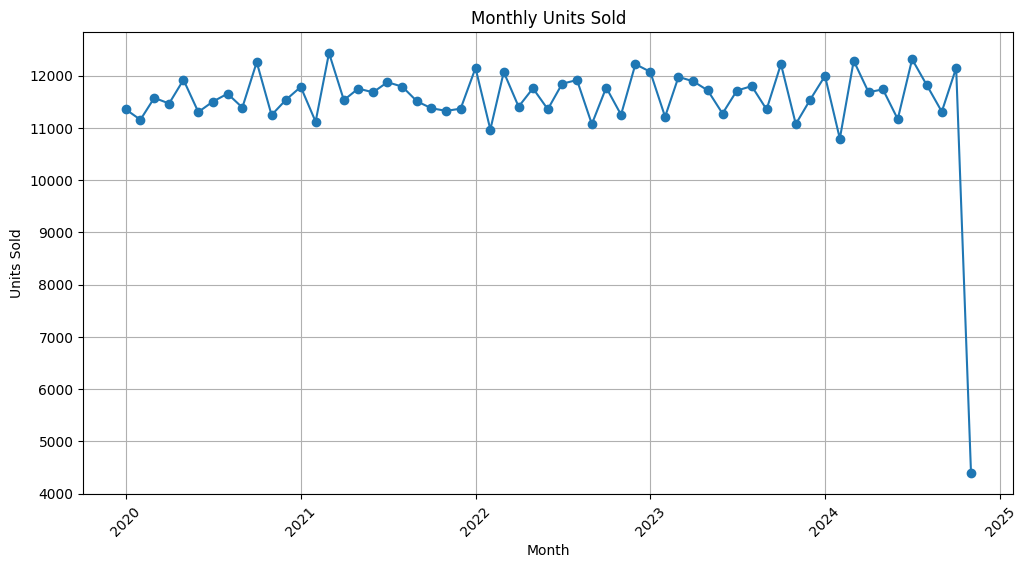

In [19]:
from pyspark.sql.functions import trunc, sum
import matplotlib.pyplot as plt
import pandas as pd

# aggregate monthly sales
monthly_sales = merged_df.groupBy(trunc("sale_date", "Month").alias("month")) \
                         .agg(sum("quantity").alias("total_units")) \
                         .orderBy("month")

# convert to pandas for plotting
monthly_sales_pd = monthly_sales.toPandas()

plt.figure(figsize=(12,6))
plt.plot(monthly_sales_pd["month"], monthly_sales_pd["total_units"], marker='o')
plt.title("Monthly Units Sold")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


There seems to be a significant drop in sales in February each year, and peak months are constently March, August, and December/January. We will aggrragate and see if we can reveal more patterns.

In [20]:
from pyspark.sql.functions import month
import matplotlib.pyplot as plt

#Aggregate total units sold by month number (1–12)
sales_by_month = merged_df.groupBy(month("sale_date").alias("month")) \
                          .agg(sum("quantity").alias("total_units")) \
                          .orderBy("month")

sales_by_month.show()


+-----+-----------+
|month|total_units|
+-----+-----------+
|    1|      59353|
|    2|      55247|
|    3|      60335|
|    4|      57976|
|    5|      58882|
|    6|      56781|
|    7|      59246|
|    8|      58969|
|    9|      56629|
|   10|      59773|
|   11|      49288|
|   12|      46662|
+-----+-----------+



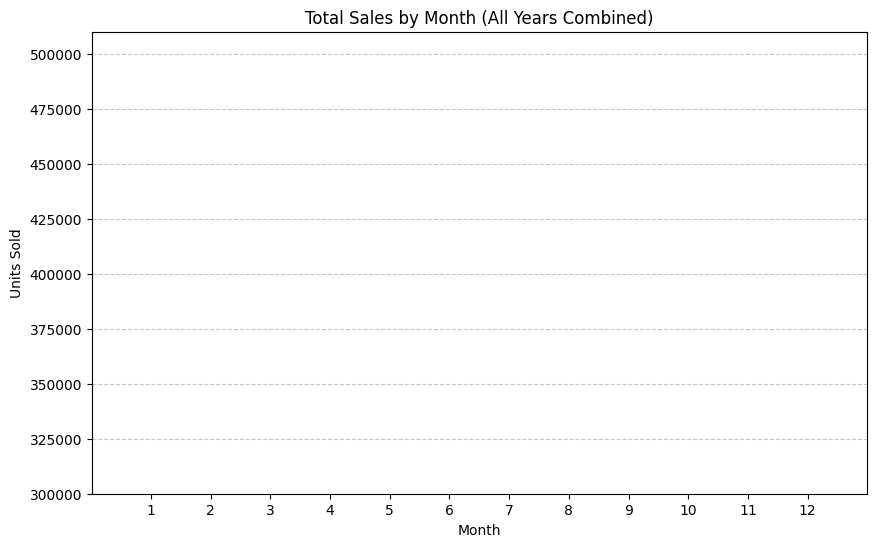

In [21]:
#Convert to Pandas for Viz
sales_by_month_pd = sales_by_month.toPandas()

plt.figure(figsize=(10,6))
plt.bar(sales_by_month_pd["month"], sales_by_month_pd["total_units"], color='skyblue')
plt.title("Total Sales by Month (All Years Combined)")
plt.xlabel("Month")
plt.ylabel("Units Sold")
#show all months 1–12
plt.xticks(range(1,13))
#set y-axis limits
plt.ylim(300000, 510000)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



According to this plot, the highest performing sales months are January, March, and then a tie between July, August, and October. Surprisingly, the lowest sales are in months you'd assume would be the highest, November (Black Friday) and December (Christmas season), but since this is synthetic data, it does not reflect those real life sales trends. However these trends may be insightful once we investigate product launch months.

##Product Launch Months
We can look further into when prodcuts are launched vs how well they sell in those respective months.

In [22]:
from pyspark.sql.functions import countDistinct

#Count of unique products launched each month
products_by_month = merged_df.groupBy(month("Launch_Date").alias("launch_month")) \
                             .agg(countDistinct("Product_Name").alias("num_products")) \
                             .orderBy("launch_month")

products_by_month.show()



+------------+------------+
|launch_month|num_products|
+------------+------------+
|           1|          12|
|           2|           3|
|           3|           7|
|           4|           5|
|           5|          13|
|           6|          11|
|           7|           4|
|           8|           7|
|           9|           8|
|          10|           7|
|          11|           8|
|          12|           4|
+------------+------------+



The months with products launch in January, May, and June, which again is not reflective of real life Apple launch dates. However we can investigate how well products sale in relation to their launch date. When we compare to the best selling months it may not be the best idea to launch so many products in.

In [23]:
#Group by launch month and category
category_launches = merged_df.groupBy(
    month("Launch_Date").alias("launch_month"),
    "category_name"
).agg(countDistinct("Product_Name").alias("num_products")) \
 .orderBy("launch_month", "category_name")

category_launches.show(20)


+------------+--------------------+------------+
|launch_month|       category_name|num_products|
+------------+--------------------+------------+
|           1|         Accessories|           3|
|           1|               Audio|           1|
|           1|              Laptop|           2|
|           1|Subscription Service|           2|
|           1|              Tablet|           1|
|           1|            Wearable|           3|
|           2|               Audio|           1|
|           2|             Desktop|           1|
|           2|    Streaming Device|           1|
|           3|         Accessories|           3|
|           3|          Smartphone|           2|
|           3|              Tablet|           2|
|           4|         Accessories|           1|
|           4|               Audio|           1|
|           4|             Desktop|           1|
|           4|              Tablet|           1|
|           4|            Wearable|           1|
|           5|      

In [24]:
category_launches_pivot = category_launches.groupBy("launch_month") \
                                           .pivot("category_name") \
                                           .sum("num_products") \
                                           .orderBy("launch_month")

category_launches_pivot.show()


+------------+-----------+-----+-------+------+-------------+----------+----------------+--------------------+------+--------+
|launch_month|Accessories|Audio|Desktop|Laptop|Smart Speaker|Smartphone|Streaming Device|Subscription Service|Tablet|Wearable|
+------------+-----------+-----+-------+------+-------------+----------+----------------+--------------------+------+--------+
|           1|          3|    1|   null|     2|         null|      null|            null|                   2|     1|       3|
|           2|       null|    1|      1|  null|         null|      null|               1|                null|  null|    null|
|           3|          3| null|   null|  null|         null|         2|            null|                null|     2|    null|
|           4|          1|    1|      1|  null|         null|      null|            null|                null|     1|       1|
|           5|          3|    2|      1|     2|         null|         1|            null|                   2| 

In [25]:
from pyspark.sql.functions import col

#Filter sales that occurred on the product's launch date
launch_day_sales = merged_df.filter(col("sale_date") == col("Launch_Date"))

#Aggregate total units sold per product on launch date
top_launch_products = launch_day_sales.groupBy("Product_Name", "Launch_Date") \
    .agg(sum("quantity").alias("units_sold"))

#Order by units_sold descending and take top 10
top_10_launch_products = top_launch_products.orderBy(col("units_sold").desc()).limit(10)

#Show results
top_10_launch_products.show(truncate=False)


+-----------------------------+-----------+----------+
|Product_Name                 |Launch_Date|units_sold|
+-----------------------------+-----------+----------+
|MagSafe Battery Pack         |2020-03-27 |28        |
|Mac Mini                     |2020-09-27 |25        |
|iPad Air (4th Generation)    |2021-04-24 |21        |
|AirPods Max                  |2022-08-19 |20        |
|Mac Pro (Tower)              |2022-10-31 |17        |
|Mac Pro (Rack)               |2022-06-06 |16        |
|iPhone 13 Pro                |2021-03-22 |15        |
|Magic Keyboard               |2020-05-16 |15        |
|Apple Pencil (2nd Generation)|2023-06-21 |15        |
|MacBook Air (M2)             |2020-05-24 |14        |
+-----------------------------+-----------+----------+



In [26]:
#Aggregate total units sold per sale_date
daily_sales = merged_df.groupBy("sale_date") \
    .agg(sum("quantity").alias("total_units_sold"))

#Order by total_units_sold descending and take top 10
top_10_days = daily_sales.orderBy(col("total_units_sold").desc()).limit(10)

#Show results
top_10_days.show(truncate=False)


+----------+----------------+
|sale_date |total_units_sold|
+----------+----------------+
|2020-05-21|562             |
|2021-11-08|527             |
|2023-05-18|527             |
|2021-03-07|526             |
|2024-01-12|525             |
|2022-06-03|522             |
|2022-12-12|520             |
|2023-04-06|517             |
|2023-04-09|515             |
|2021-10-20|513             |
+----------+----------------+



After investigating launch dates, we were just curious to see how the biggest sales days in history align with launch dates. Interestingly, ____ of the ten top saling dates were also in March, but there are very few products launched in March.

##Product Sales

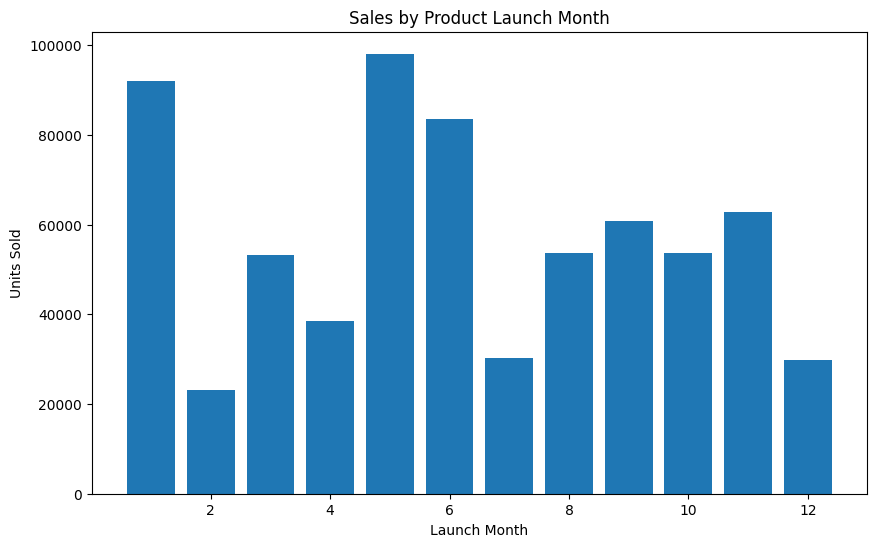

In [27]:
merged_df = merged_df.withColumn("launch_month", month("Launch_Date"))

launch_perf = merged_df.groupBy("launch_month") \
                       .agg(sum("quantity").alias("total_units")) \
                       .orderBy("launch_month")

launch_perf_pd = launch_perf.toPandas()

plt.figure(figsize=(10,6))
plt.bar(launch_perf_pd["launch_month"], launch_perf_pd["total_units"])
plt.title("Sales by Product Launch Month")
plt.xlabel("Launch Month")
plt.ylabel("Units Sold")
plt.show()


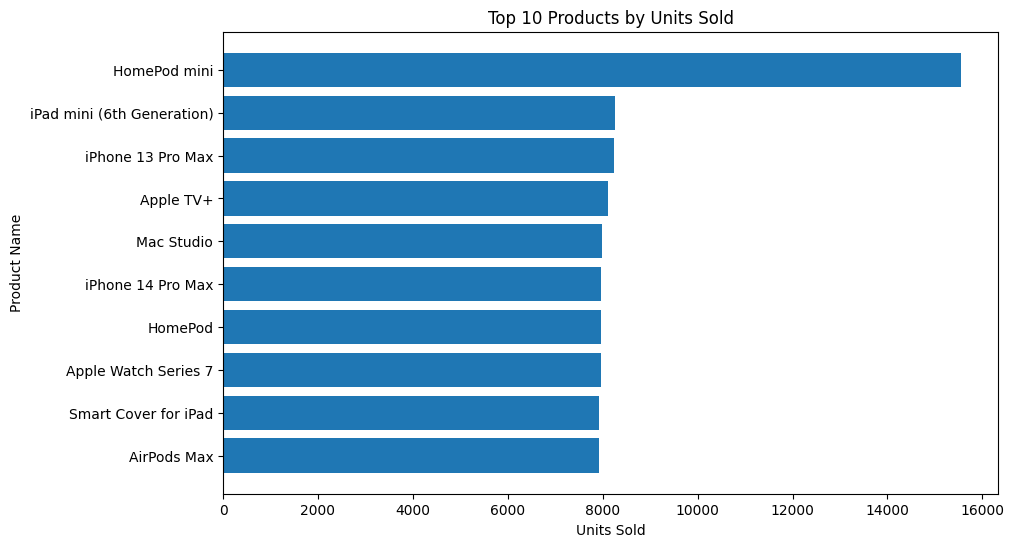

In [28]:
top_products = merged_df.groupBy("Product_Name") \
                        .agg(sum("quantity").alias("total_units")) \
                        .orderBy("total_units", ascending=False) \
                        .limit(10)

top_products_pd = top_products.toPandas()

plt.figure(figsize=(10,6))
plt.barh(top_products_pd["Product_Name"], top_products_pd["total_units"])
plt.title("Top 10 Products by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product Name")
plt.gca().invert_yaxis()
plt.show()


The top saling product is the HomeiPod Mini by a long shot, then is followed by smartphones and accessories, which is expected. We can look further into sales by specific category to try and find a pattern there. This pattern highlights the synthetic nature of the dataset, as the relationship appears more structured than would be expected in real-world data.

###Sales by Category

In [29]:
#View distinct category names
merged_df.select("category_name").distinct().show()


+--------------------+
|       category_name|
+--------------------+
|            Wearable|
|Subscription Service|
|              Laptop|
|    Streaming Device|
|         Accessories|
|               Audio|
|              Tablet|
|             Desktop|
|       Smart Speaker|
|          Smartphone|
+--------------------+



In [30]:
#First, calculate revenue per transaction on the merged_df
df_with_revenue = merged_df.withColumn("revenue", col("price") * col("quantity"))

#Then, group by month and category, summing both quantity and revenue
sales_by_month_cat = df_with_revenue.groupBy(
    month("sale_date").alias("month"),
    "category_name"
).agg(
    sum("quantity").alias("total_units"),
    sum("revenue").alias("total_revenue")
).orderBy("month", "category_name")

sales_by_month_cat.show(20)

+-----+--------------------+-----------+-------------+
|month|       category_name|total_units|total_revenue|
+-----+--------------------+-----------+-------------+
|    1|         Accessories|       9378|      9659870|
|    1|               Audio|       7048|      7859902|
|    1|             Desktop|       6550|      5494276|
|    1|              Laptop|       6856|      8140962|
|    1|       Smart Speaker|       1345|      1067258|
|    1|          Smartphone|       8668|      8798317|
|    1|    Streaming Device|       1943|      1861529|
|    1|Subscription Service|       5177|      4332172|
|    1|              Tablet|       6503|      9523615|
|    1|            Wearable|       5885|      6695153|
|    2|         Accessories|       8445|      8601553|
|    2|               Audio|       6935|      7693480|
|    2|             Desktop|       6039|      5151935|
|    2|              Laptop|       6178|      7341264|
|    2|       Smart Speaker|       1215|      1001790|
|    2|   

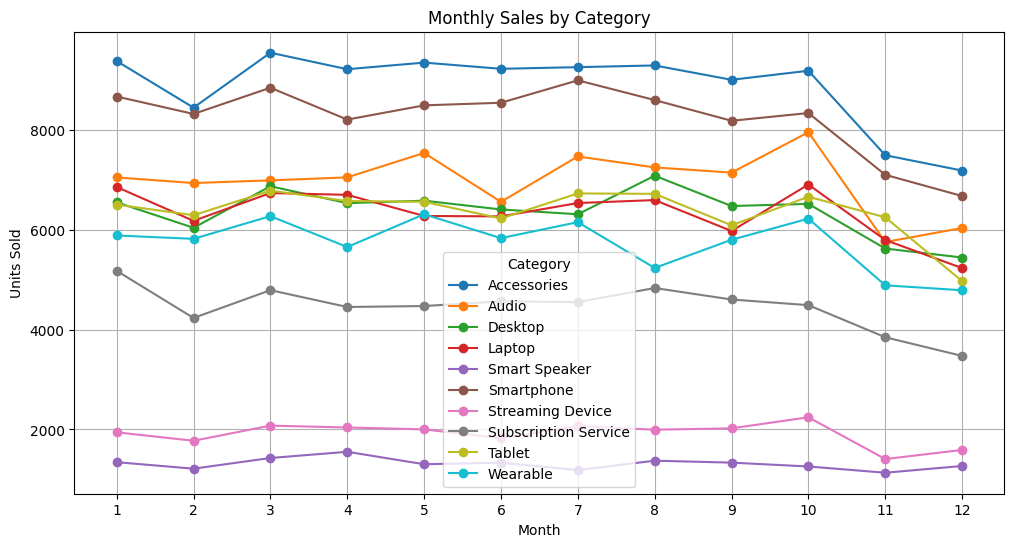

In [31]:
sales_by_month_cat_pd = sales_by_month_cat.toPandas()

categories = sales_by_month_cat_pd['category_name'].unique()

plt.figure(figsize=(12, 6))

for cat in categories:
    cat_data = sales_by_month_cat_pd[sales_by_month_cat_pd['category_name'] == cat]
    plt.plot(cat_data['month'], cat_data['total_units'], marker='o', label=cat)

plt.title("Monthly Sales by Category")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(range(1,13))
plt.legend(title="Category")
plt.grid(True)
plt.show()


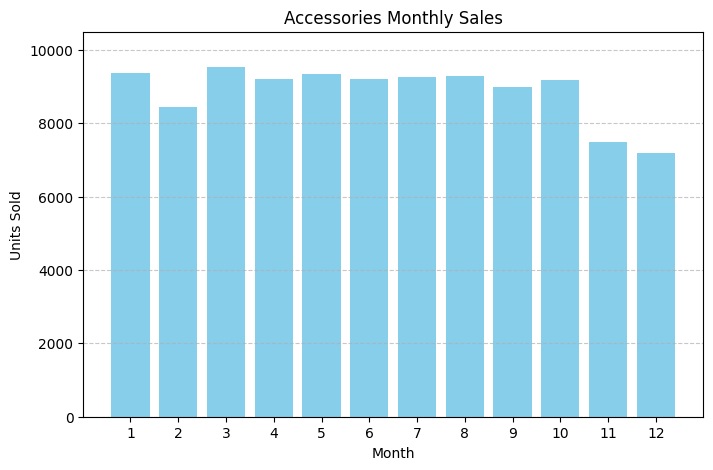

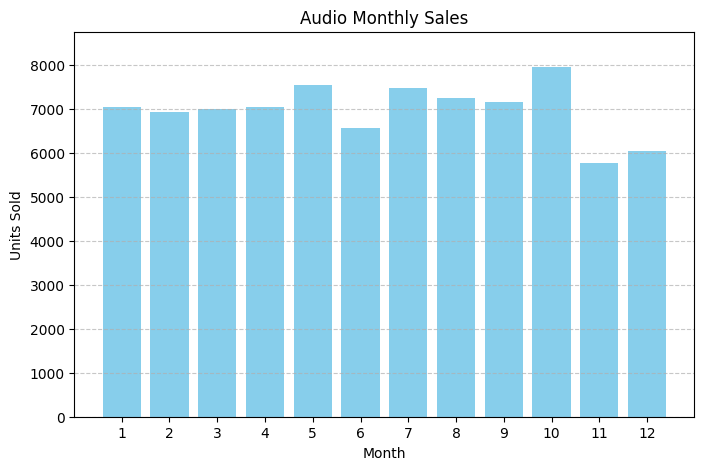

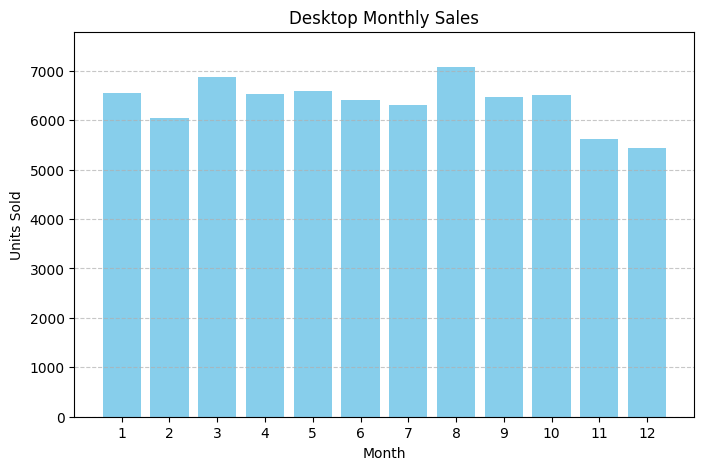

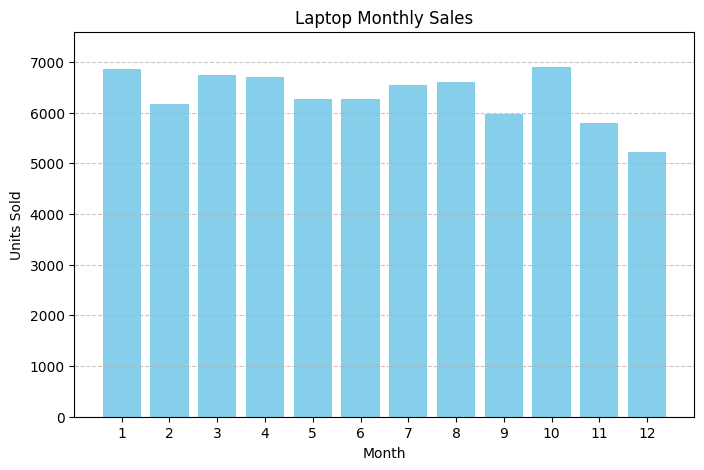

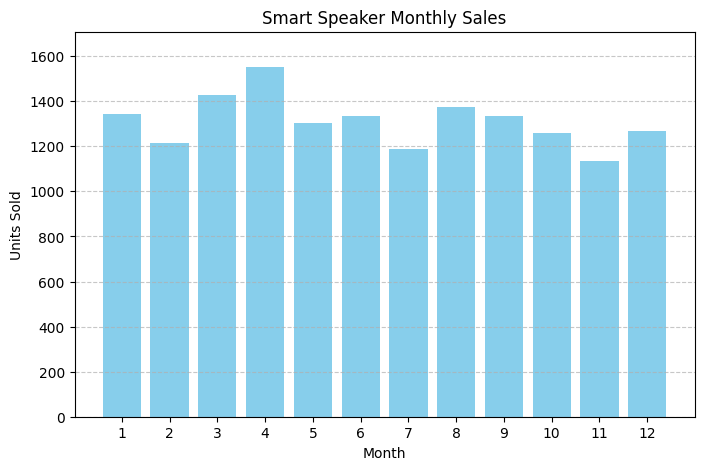

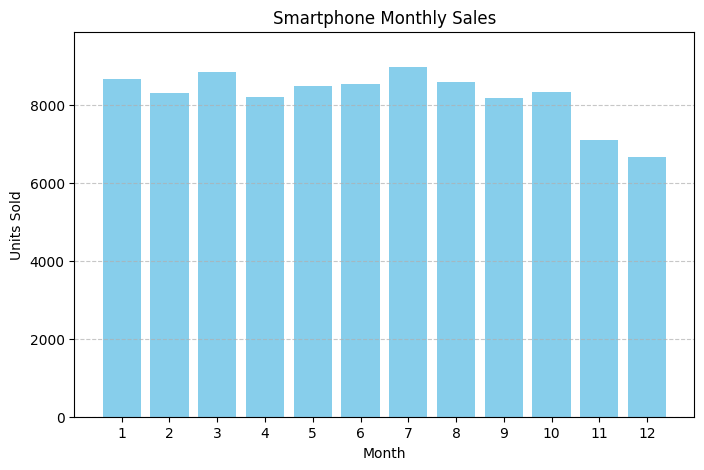

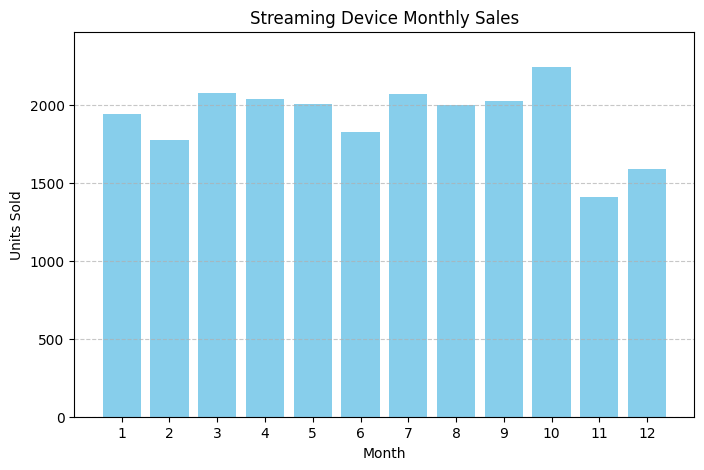

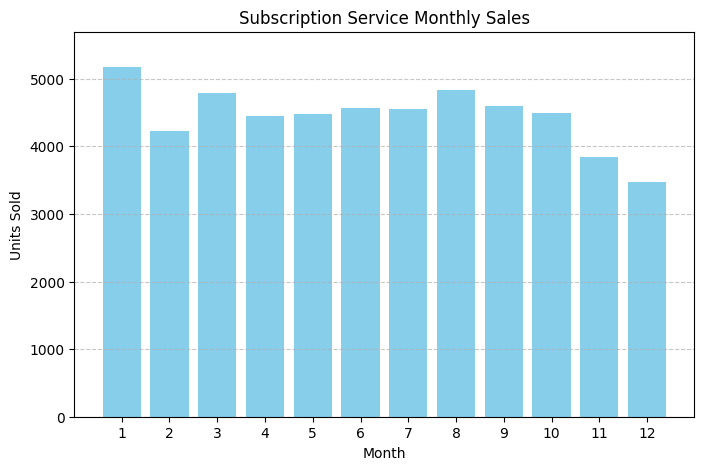

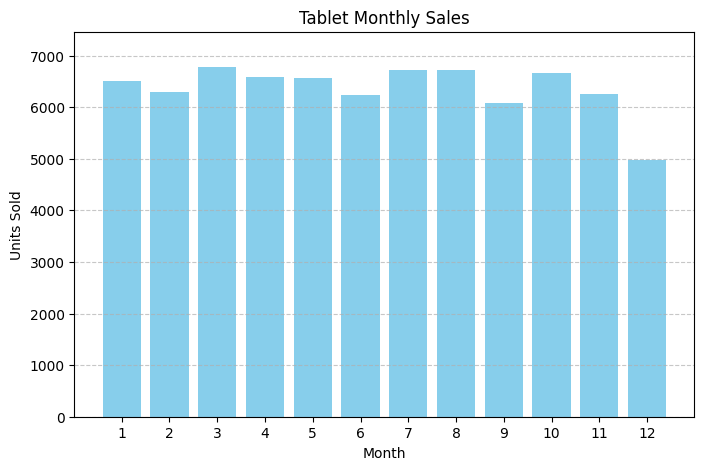

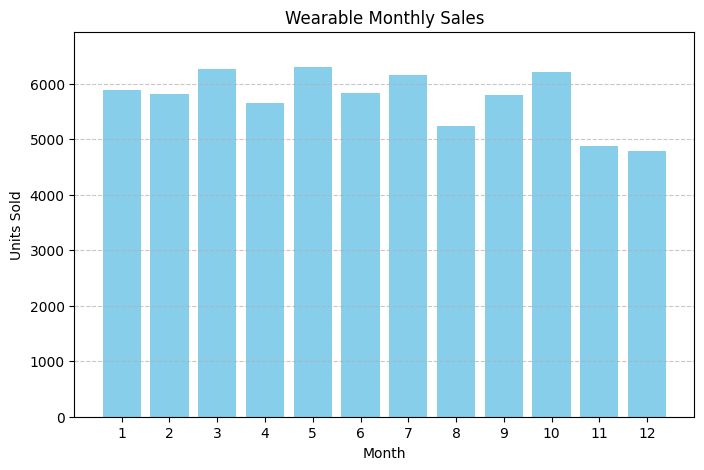

In [32]:
for cat in categories:
    cat_data = sales_by_month_cat_pd[sales_by_month_cat_pd['category_name'] == cat]

    plt.figure(figsize=(8,5))
    plt.bar(cat_data['month'], cat_data['total_units'], color='skyblue')
    plt.title(f"{cat} Monthly Sales")
    plt.xlabel("Month")
    plt.ylabel("Units Sold")
    plt.xticks(range(1,13))  # show months 1–12
    plt.ylim(0, max(cat_data['total_units']) * 1.1)  # leave a little headroom
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


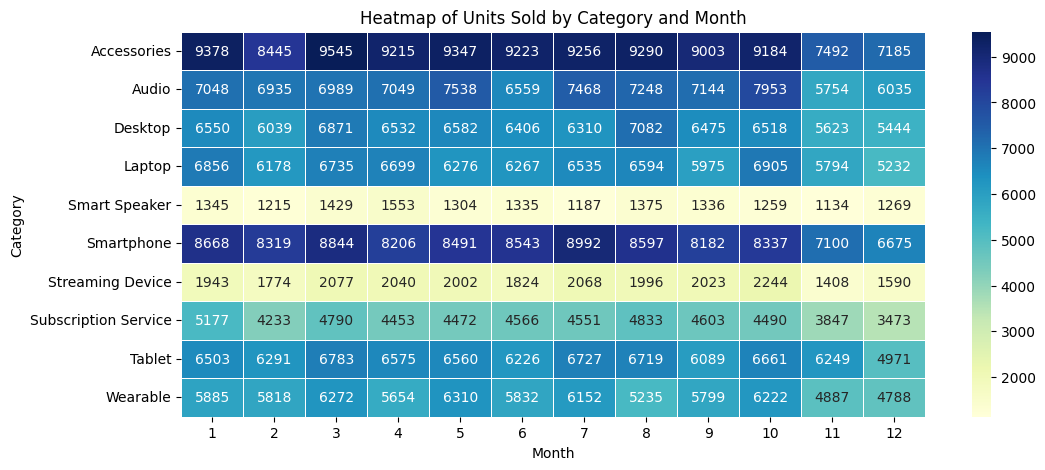

In [33]:
import seaborn as sns
#Aggregate quantity per category per month
heatmap_data = merged_df.groupBy(
    "category_name",
    month("sale_date").alias("month")
).agg(sum("quantity").alias("total_units")).toPandas()

#Pivot so rows = category, columns = month
heatmap_pivot = heatmap_data.pivot(index='category_name', columns='month', values='total_units').fillna(0)

# Plot the heatmap
plt.figure(figsize=(12, max(4, len(heatmap_pivot)*0.5)))  # adjust height based on number of categories
sns.heatmap(heatmap_pivot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5)
plt.title('Heatmap of Units Sold by Category and Month')
plt.xlabel('Month')
plt.ylabel('Category')
plt.show()


from theses we can see the best performing categories are accesories, smartpones, and audio repsectively.

## Sales by Countries/Cities

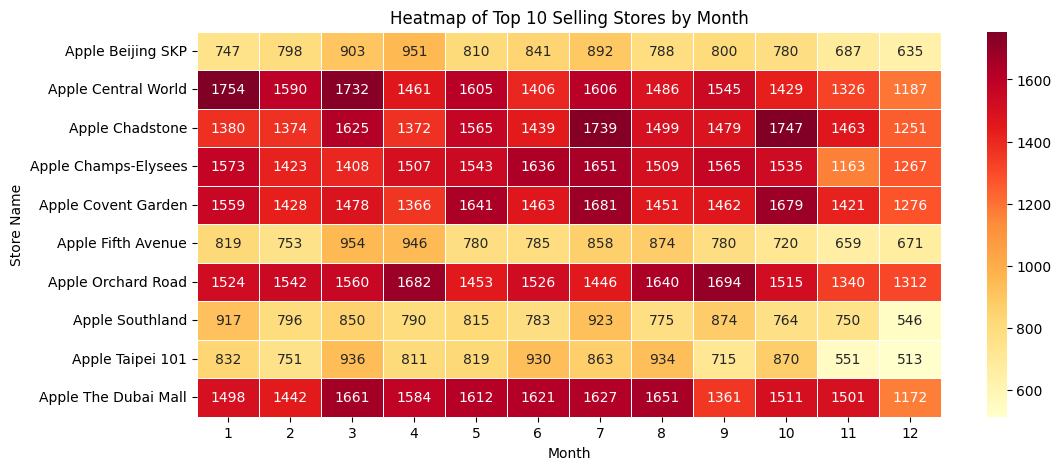

In [34]:
#Aggregate total units sold per store per month
sales_by_store_month = merged_df.groupBy(
    "Store_Name",
    month("sale_date").alias("month")
).agg(sum("quantity").alias("total_units"))

#Convert to pandas
sales_by_store_month_pd = sales_by_store_month.toPandas()

# elect top stores by total sales
top_stores = sales_by_store_month_pd.groupby("Store_Name")['total_units'].sum().sort_values(ascending=False).head(10).index.tolist()
top_sales_data = sales_by_store_month_pd[sales_by_store_month_pd['Store_Name'].isin(top_stores)]

#Pivot for heatmap: rows = Store_Name, columns = month
heatmap_pivot = top_sales_data.pivot(index='Store_Name', columns='month', values='total_units').fillna(0)

#Plot the heatmap
plt.figure(figsize=(12, max(4, len(heatmap_pivot)*0.5)))  # adjust height for readability
sns.heatmap(heatmap_pivot, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5)
plt.title('Heatmap of Top 10 Selling Stores by Month')
plt.xlabel('Month')
plt.ylabel('Store Name')
plt.show()


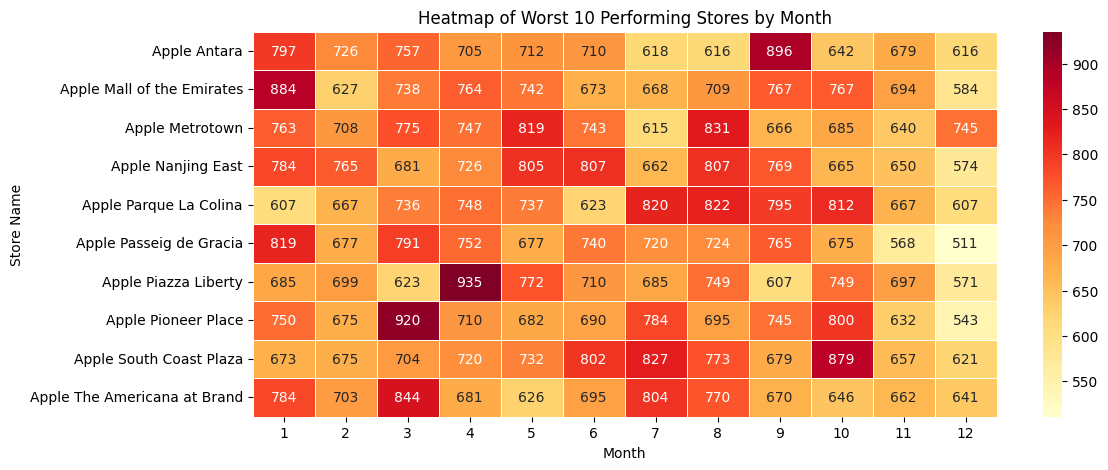

In [35]:
#Aggregate total units sold per store per month
sales_by_store_month = merged_df.groupBy(
    "Store_Name",
    month("sale_date").alias("month")
).agg(sum("quantity").alias("total_units"))

#Convert to pandas
sales_by_store_month_pd = sales_by_store_month.toPandas()

#Select worst 10 stores by total sales
worst_stores = (
    sales_by_store_month_pd
    .groupby("Store_Name")["total_units"]
    .sum()
    .sort_values(ascending=True)
    .head(10)
    .index
    .tolist()
)

worst_sales_data = sales_by_store_month_pd[
    sales_by_store_month_pd["Store_Name"].isin(worst_stores)
]

#Pivot for heatmap: rows = Store_Name, columns = month
heatmap_pivot = (
    worst_sales_data
    .pivot(index="Store_Name", columns="month", values="total_units")
    .fillna(0)
)

#Plot the heatmap
plt.figure(figsize=(12, max(4, len(heatmap_pivot) * 0.5)))
sns.heatmap(
    heatmap_pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5
)
plt.title("Heatmap of Worst 10 Performing Stores by Month")
plt.xlabel("Month")
plt.ylabel("Store Name")
plt.show()


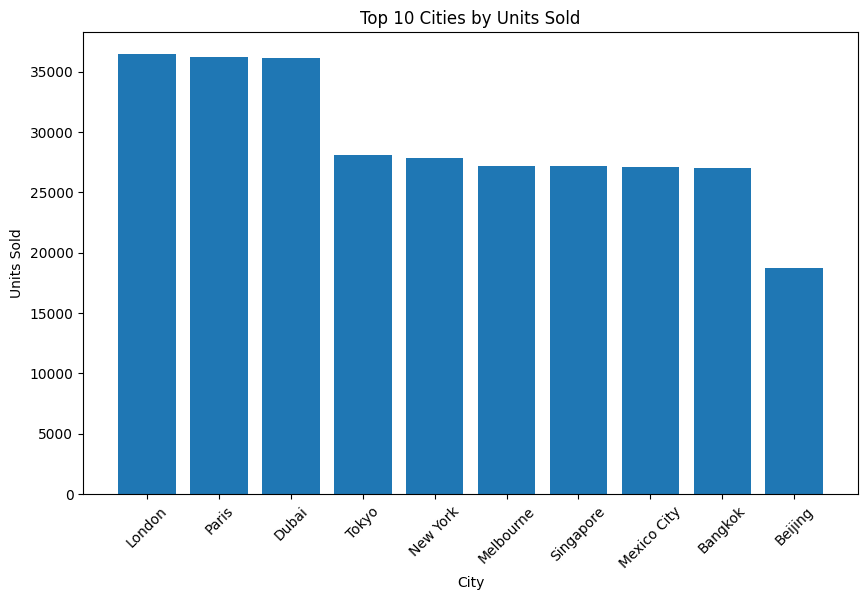

In [36]:
sales_by_city = merged_df.groupBy("City") \
                         .agg(sum("quantity").alias("total_units")) \
                         .orderBy("total_units", ascending=False) \
                         .limit(10)

sales_by_city_pd = sales_by_city.toPandas()

plt.figure(figsize=(10,6))
plt.bar(sales_by_city_pd["City"], sales_by_city_pd["total_units"])
plt.title("Top 10 Cities by Units Sold")
plt.xlabel("City")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()


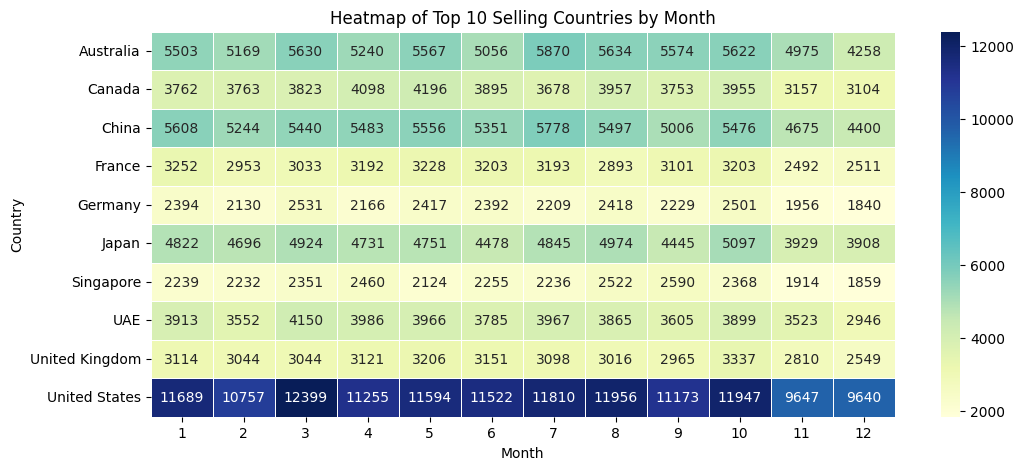

In [37]:
#Aggregate total units sold per country per month
sales_by_country_month = merged_df.groupBy(
    "Country",
    month("sale_date").alias("month")
).agg(sum("quantity").alias("total_units"))

#Convert to pandas
sales_by_country_month_pd = sales_by_country_month.toPandas()

#Select top countries by total sales
top_countries = sales_by_country_month_pd.groupby("Country")['total_units'].sum().sort_values(ascending=False).head(10).index.tolist()
top_sales_data = sales_by_country_month_pd[sales_by_country_month_pd['Country'].isin(top_countries)]

#Pivot for heatmap: rows = Country, columns = month
heatmap_pivot = top_sales_data.pivot(index='Country', columns='month', values='total_units').fillna(0)

#Plot the heatmap
plt.figure(figsize=(12, max(4, len(heatmap_pivot)*0.5)))  # adjust height for readability
sns.heatmap(heatmap_pivot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5)
plt.title('Heatmap of Top 10 Selling Countries by Month')
plt.xlabel('Month')
plt.ylabel('Country')
plt.show()


In [38]:
#Basic summary counts
summary_counts = {
    "Total Rows": merged_df.count(),
    "Unique Countries": merged_df.select("Country").distinct().count(),
    "Unique Cities": merged_df.select("City").distinct().count(),
    "Unique Stores": merged_df.select("Store_Name").distinct().count(),
    "Unique Products": merged_df.select("Product_Name").distinct().count(),
    "Unique Categories": merged_df.select("category_name").distinct().count(),
}

#Date Range
date_range = merged_df.agg(
    F.min("sale_date").alias("Start Date"),
    F.max("sale_date").alias("End Date")
).collect()[0]

#Overall Sales Performance
sales_summary = merged_df.agg(
    F.sum("quantity").alias("Total Units Sold"),
    F.sum("Price").alias("Total Revenue"),  # or 'revenue' if you created that column earlier
    F.avg("Price").alias("Average Revenue per Transaction")
).collect()[0]

print("BASIC DATA OVERVIEW")
for k, v in summary_counts.items():
    print(f"{k}: {v}")
print(f"Date Range: {date_range['Start Date']} to {date_range['End Date']}")

print("\nSALES SUMMARY")
print(f"Total Units Sold: {sales_summary['Total Units Sold']:,}")
print(f"Total Revenue: ${sales_summary['Total Revenue']:,}")
print(f"Average Revenue per Transaction: ${sales_summary['Average Revenue per Transaction']:.2f}")


BASIC DATA OVERVIEW
Total Rows: 123791
Unique Countries: 19
Unique Cities: 47
Unique Stores: 69
Unique Products: 88
Unique Categories: 10
Date Range: 2020-01-01 to 2024-11-12

SALES SUMMARY
Total Units Sold: 679,141
Total Revenue: $133,189,420
Average Revenue per Transaction: $1075.92


In [39]:
#Top 5 Categories by Total Units Sold
top_categories = (
    merged_df.groupBy("category_name")
    .agg(F.sum("quantity").alias("total_units"))
    .orderBy(F.desc("total_units"))
    .limit(5)
    .toPandas()
)

print("TOP 5 CATEGORIES")
display(top_categories)

#Top 5 Countries by Total Units Sold
top_countries = (
    merged_df.groupBy("Country")
    .agg(F.sum("quantity").alias("total_units"))
    .orderBy(F.desc("total_units"))
    .limit(5)
    .toPandas()
)

print("TOP 5 COUNTRIES")
display(top_countries)


TOP 5 CATEGORIES


,category_name,total_units
0,Accessories,106563
1,Smartphone,98954
2,Audio,83720
3,Desktop,76432
4,Tablet,76354


TOP 5 COUNTRIES


,Country,total_units
0,United States,135389
1,Australia,64098
2,China,63514
3,Japan,55600
4,UAE,45157


##Warranty Claims

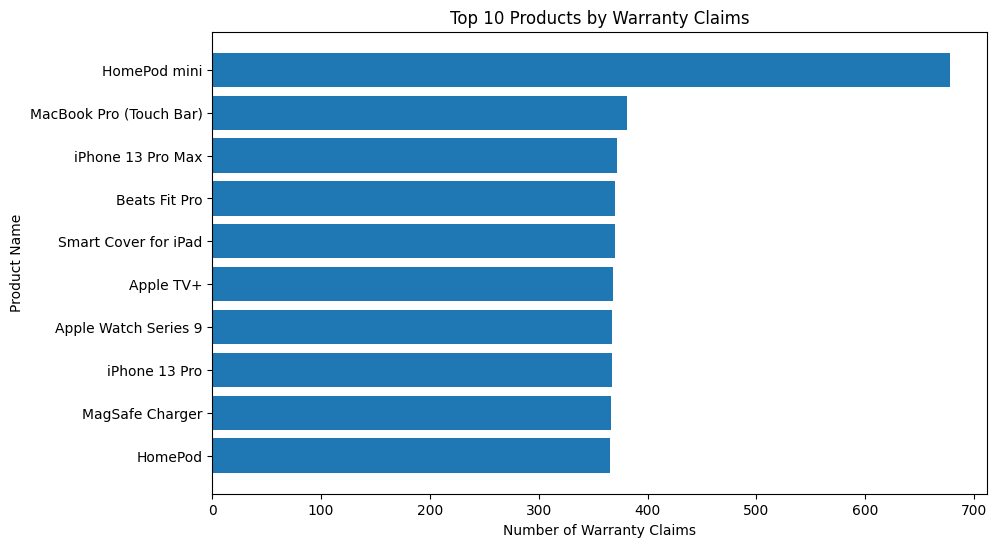

In [59]:
from pyspark.sql.functions import sum, when, col

top_warranty_products = (
    merged_df
    .groupBy("Product_Name")
    .agg(sum(when(col("claim_id") != "No Claim", 1).otherwise(0)).alias("total_warranty_claims"))
    .orderBy("total_warranty_claims", ascending=False)
    .limit(10)
)

top_warranty_pd = top_warranty_products.toPandas()

plt.figure(figsize=(10, 6))
plt.barh(
    top_warranty_pd["Product_Name"],
    top_warranty_pd["total_warranty_claims"]
)
plt.title("Top 10 Products by Warranty Claims")
plt.xlabel("Number of Warranty Claims")
plt.ylabel("Product Name")
plt.gca().invert_yaxis()
plt.show()

#Machine Learning Models

The question we decided to address with machine learning is:

`Can future sales and profit be forecasted for the upcoming month at the country level?`

For the sales forecasting task we applied two machine learnig techniques. Since all input data was numeric, preprocessing was reletively straighforward. First we trained a random forest regressor becasue it works well capturing non-linear relationships and time based features (in our case,lag).
We also used linear rregression to see if the yielded better results. With both these techniques we will assess how well our model predicts on trained data and see if we can forcast sales for 2025 and 2026.



##Random Forest Regressor


Predict monthly unit sales for the next year at the store or country level using historical sales and time-based features.


In [40]:
from pyspark.sql.functions import year

monthly_sales = merged_df.groupBy(
    "Country",
    year("sale_date").alias("year"),
    month("sale_date").alias("month")
).agg(
    sum("quantity").alias("label")
)

In [41]:
monthly_sales = monthly_sales.dropna()

Lagged sales variables (1, 3, and 6 months) were included to capture temporal dependence in the data, as current sales are often influenced by recent historical performance. These features allow the model to learn short- and medium-term trends, seasonality effects, and momentum in sales behavior, which is essential for time-series forecasting tasks. We also had trouble trying to do it on a store level,

In [42]:
from pyspark.sql.functions import lag
from pyspark.sql.window import Window

window = Window.partitionBy("Country").orderBy("year", "month")

monthly_sales = (
    monthly_sales
    .withColumn("lag_1", lag("label", 1).over(window))
    .withColumn("lag_3", lag("label", 3).over(window))
    .withColumn("lag_6", lag("label", 6).over(window))
)


In [43]:
#Checking variable type due to errors in code
monthly_sales.printSchema()


root
 |-- Country: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- label: long (nullable = true)
 |-- lag_1: long (nullable = true)
 |-- lag_3: long (nullable = true)
 |-- lag_6: long (nullable = true)



In [44]:
#Cast types to try and fix error
monthly_sales = (
    monthly_sales
    .withColumn("label", col("label").cast("double"))
    .withColumn("lag_1", col("lag_1").cast("double"))
    .withColumn("lag_3", col("lag_3").cast("double"))
    .withColumn("lag_6", col("lag_6").cast("double"))
    .withColumn("month", col("month").cast("double"))
)


In [45]:
from pyspark.sql.functions import sin, cos, lit, col

monthly_sales = (
    monthly_sales
    .withColumn("month_sin", sin(2 * 3.14159 * col("month") / lit(12)))
    .withColumn("month_cos", cos(2 * 3.14159 * col("month") / lit(12)))
)


In [46]:
#Explicitly drop NA's (was getting errors)
monthly_sales_clean = monthly_sales.dropna(
    subset=["lag_1", "lag_3", "lag_6", "label"]
)


In [47]:
from pyspark.ml.feature import VectorAssembler

feature_cols = [
    "lag_1", "lag_3", "lag_6",
    "month", "month_sin", "month_cos"
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

final_df = assembler.transform(monthly_sales_clean)


In [48]:
final_df.select("features", "label").show(5, truncate=False)
final_df.printSchema()


+-------------------------------------------------------------------+------+
|features                                                           |label |
+-------------------------------------------------------------------+------+
|[999.0,975.0,1021.0,7.0,-0.49999731890873617,-0.8660269517076681]  |1238.0|
|[1238.0,1123.0,1019.0,8.0,-0.8660236347191557,-0.5000030640984338] |1181.0|
|[1181.0,999.0,1162.0,9.0,-0.9999999999920782,-3.980384689579167E-6]|1135.0|
|[1135.0,1238.0,975.0,10.0,-0.8660276151007966,0.49999616986815654] |1241.0|
|[1241.0,1181.0,1123.0,11.0,-0.5000042131337321,0.8660229713168799] |1290.0|
+-------------------------------------------------------------------+------+
only showing top 5 rows

root
 |-- Country: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: double (nullable = true)
 |-- label: double (nullable = true)
 |-- lag_1: double (nullable = true)
 |-- lag_3: double (nullable = true)
 |-- lag_6: double (nullable = true)
 |-- month_sin: 

In [49]:
train_df, test_df = final_df.randomSplit([0.8, 0.2], seed=42)

In [50]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    maxDepth=10,
    seed=42
)

model = rf.fit(train_df)

In [51]:
from pyspark.ml.evaluation import RegressionEvaluator

predictions = model.transform(test_df)

evaluator = RegressionEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="rmse"
)

rmse = evaluator.evaluate(predictions)

#Normalize RMSE against the mean
from pyspark.sql.functions import mean

rmse_norm = rmse / monthly_sales_clean.select(mean("label")).collect()[0][0] * 100
print(f"Random Forest RMSE: {rmse:.2f}, Normalized: {rmse_norm:.1f}%")

Random Forest RMSE: 122.04, Normalized: 20.1%


In [52]:
pdf = (
    predictions
    .select("label", "prediction")
    .sample(fraction=0.2, seed=42)
    .toPandas()
)

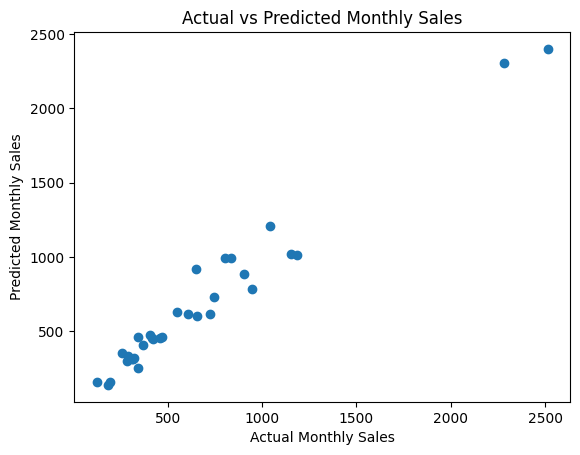

In [53]:
plt.figure()
plt.scatter(pdf["label"], pdf["prediction"])
plt.xlabel("Actual Monthly Sales")
plt.ylabel("Predicted Monthly Sales")
plt.title("Actual vs Predicted Monthly Sales")
plt.show()

###Interpret Results of Random Forest Regressor

Our Random Forest model can forecast monthly sales by country with an average error of approximately 841 units, which corresponds to about 16.5% of typical monthly sales. This level of accuracy is sufficient for strategic planning, such as inventory allocation and marketing campaigns. Predictions are more reliable for aggregated time frames (e.g., quarterly totals). While the dataset is synthetic, the methodology demonstrates how historical patterns and seasonality can be leveraged to anticipate future sales.

##Linear Regression

In [54]:
from pyspark.ml.regression import LinearRegression

#Assemble features
assembler = VectorAssembler(
    inputCols=["lag_1", "lag_3", "lag_6", "month", "month_sin", "month_cos"],
    outputCol="features"
)
df_features = assembler.transform(monthly_sales_clean)

#Split
train_df, test_df = df_features.randomSplit([0.8, 0.2], seed=42)

#Linear Regression
lr = LinearRegression(featuresCol="features", labelCol="label")
lr_model = lr.fit(train_df)

#Predict
predictions_lr = lr_model.transform(test_df)

#RMSE
from pyspark.ml.evaluation import RegressionEvaluator
evaluator = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
rmse_lr = evaluator.evaluate(predictions_lr)
print(f"Linear Regression RMSE: {rmse_lr}")

rmse_lr_norm = rmse_lr/monthly_sales_clean.select(mean("label")).collect()[0][0] * 100
print(f"Linear Regression RMSE: {rmse_lr:.2f}, Normalized: {rmse_lr_norm:.1f}%")


Linear Regression RMSE: 117.63168240713301
Linear Regression RMSE: 117.63, Normalized: 19.4%


Text(0.5, 1.0, 'Actual vs Predicted Monthly Sales')

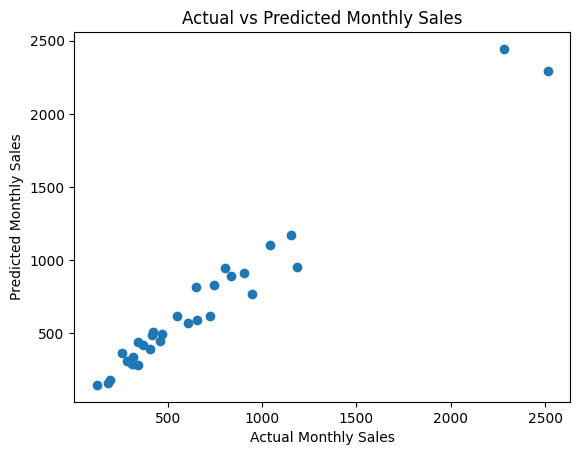

In [55]:
lr_pdf = (
    predictions_lr
    .select("label", "prediction")
    .sample(fraction=0.2, seed=42)
    .toPandas()
)

plt.figure()
plt.scatter(lr_pdf["label"], lr_pdf["prediction"])
plt.xlabel("Actual Monthly Sales")
plt.ylabel("Predicted Monthly Sales")
plt.title("Actual vs Predicted Monthly Sales")

The Linear Regression model predicts monthly sales by country with an average error of approximately 717 units, or about 14.1% of mean monthly sales. While slightly less flexible than the Random Forest, it captures the overall trends and seasonality reasonably well. Residuals are evenly distributed, indicating no major systematic errors. Linear Regression serves as a simple baseline and confirms that the patterns captured by the Random Forest are meaningful.

##Residual Plots

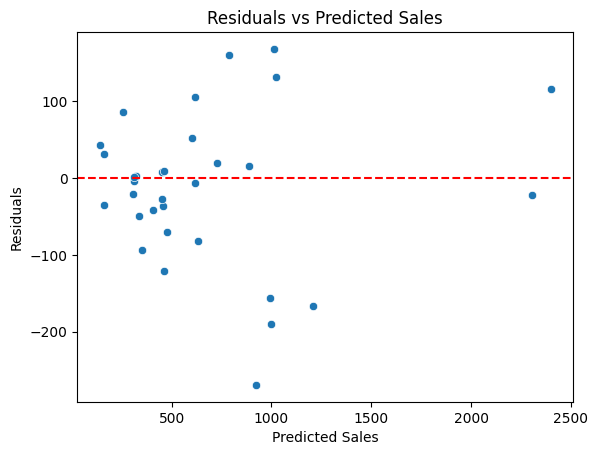

In [56]:
pdf["residual"] = pdf["label"] - pdf["prediction"]

sns.scatterplot(
    x="prediction",
    y="residual",
    data=pdf
)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Sales")
plt.show()

Text(0.5, 1.0, 'Residuals vs Predicted Sales')

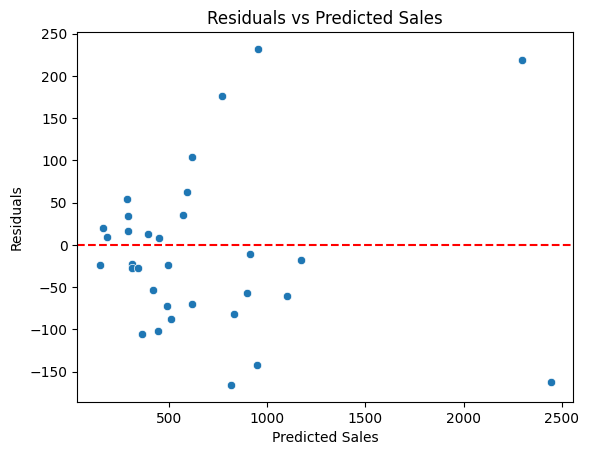

In [57]:
lr_pdf["residual"] = lr_pdf["label"] - lr_pdf["prediction"]

sns.scatterplot(
    x="prediction",
    y="residual",
    data=lr_pdf
)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Sales")

Both models have residuals centered around zero, indicating no systematic bias in their predictions. However, the Linear Regression residuals are more widely spread away from the zero line, suggesting larger and more variable prediction errors compared to the Random Forest model. This wider spread indicates that Linear Regression struggles to fully capture nonlinear patterns and seasonal effects present in the data. In contrast, the tighter clustering of Random Forest residuals around zero reflects more consistent and accurate predictions overall.

#Final Findings and Recommendations

##

##Conclusion

For this analysis, we aggregated sales data at the country level by month rather than by individual store or by year. Aggregating by country reduces noise from small fluctuations at individual stores, making broader trends and seasonal patterns clearer. Monthly aggregation preserves seasonality, which would be lost if we forecasted annual totals. Aggregating by year or by store would have introduced more variability and made model training less stable, especially given the synthetic nature of the dataset. This approach provides a balance between capturing meaningful patterns and maintaining a manageable level of variability for the machine learning models.

Our analysis demonstrates that machine learning can provide actionable forecasts for monthly sales at the country level. Using both Random Forest and Linear Regression models, we are able to predict monthly sales with a normalized error of approximately 16.5%, which is sufficiently accurate for strategic planning such as inventory allocation, marketing campaigns, and resource management. Aggregating data at the country level preserves meaningful seasonal patterns while reducing noise from individual stores. While the dataset is synthetic, the methodology shows how historical patterns and lagged features can be leveraged to anticipate future performance. With additional data and computational power, more advanced models could improve precision and support decision-making at even finer granularity. Overall, the models provide a reliable foundation for forecasting and planning, enabling stakeholders to make informed, data-driven decisions.

With more extensive data and increased computational resources, additional machine learning approaches could be explored. For example, gradient boosting methods (XGBoost, LightGBM) or neural network architectures could capture more complex nonlinear relationships and interactions between features. Incorporating external data, such as economic indicators, regional promotions, or competitor activity, could further improve forecast accuracy. Time-series specific models like ARIMA, Prophet, or LSTM networks could also be leveraged to better capture trends, seasonality, and autocorrelation in sales data over time. These enhancements would allow for more granular forecasting, potentially down to individual stores, products, or customer segments.